# H0 -- Geospatial fundamentals + the smoke tile

First real slice of the [plan](../PLAN.md): raster vs vector, CRS/EPSG, spectral
indices, and both directions of the raster <-> vector conversion, all against a
real Sentinel-2 scene over Dhaka -- not synthetic data.

**Smoke tile**: a small (~25km x 22km) bounding box straddling three real
districts (Dhaka, Gazipur, Narayanganj), so the zonal-stats step has more than one
row to be meaningful, while staying small enough to run on a laptop CPU in a
couple of minutes.

In [1]:
import sys
sys.path.insert(0, '..')

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import planetary_computer
import pystac_client
import rasterio
import rasterstats
import rioxarray  # noqa: F401 -- registers the .rio accessor used below
import stackstac
from rasterio.features import shapes
from shapely.geometry import box, shape

from src.indices import ndbi, ndvi, ndwi

SMOKE_BBOX = [90.30, 23.75, 90.55, 23.95]  # lon/lat: Dhaka + Gazipur + Narayanganj corner
UTM_EPSG = 32646  # Bangladesh falls in UTM zone 46N


## 1. Cloud data access -- search a real STAC catalog

Microsoft Planetary Computer's STAC API is public: no account, no API key, just an
HTTP request. `planetary_computer.sign_inplace` signs each asset URL with a
short-lived, free SAS token at request time.

In [2]:
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=planetary_computer.sign_inplace,
)

search = catalog.search(
    collections=['sentinel-2-l2a'],
    bbox=SMOKE_BBOX,
    datetime='2026-01-01/2026-02-28',
    query={'eo:cloud_cover': {'lt': 15}},
)
items = list(search.items())
print(f'{len(items)} low-cloud Sentinel-2 scenes over the smoke tile, Jan-Feb 2026')

item = min(items, key=lambda i: i.properties['eo:cloud_cover'])
print('picked:', item.id, item.datetime.date(), f"{item.properties['eo:cloud_cover']:.3f}% cloud")


22 low-cloud Sentinel-2 scenes over the smoke tile, Jan-Feb 2026
picked: S2C_MSIL2A_20260214T042901_R133_T46QBM_20260214T080510 2026-02-14 0.001% cloud


## 2. Load real bands -- `rasterio`/`stackstac`, CRS/EPSG in practice

Sentinel-2 tile IDs encode their native UTM zone (`T46...` -> zone 46N -> EPSG:32646,
the correct CRS for Bangladesh). Loading directly in that projected CRS (rather than
reprojecting to geographic EPSG:4326) is both correct -- distances/areas in meters
need a projected CRS -- and far cheaper, since it avoids resampling every pixel.

In [3]:
stack = stackstac.stack(
    [item],
    assets=['B03', 'B04', 'B08', 'B11'],  # green, red, nir, swir
    bounds_latlon=SMOKE_BBOX,
    resolution=20,
    epsg=UTM_EPSG,
)
arr = stack.compute()  # (time, band, y, x) -- real download happens here
green, red, nir, swir = arr.isel(time=0)
print('shape (y, x):', green.shape, ' crs:', stack.rio.crs, ' nan fraction:', float(arr.isnull().mean()))
transform = stack.rio.transform()


shape (y, x): (1133, 1295)  crs: EPSG:32646  nan fraction: 5.622821156801739e-06


## 3. Spectral indices -- NDVI / NDWI / NDBI

Using [`src/indices.py`](../src/indices.py) -- the same pure functions covered by
the 8 unit tests in `tests/test_indices.py`, now run against a real scene instead
of synthetic arrays.

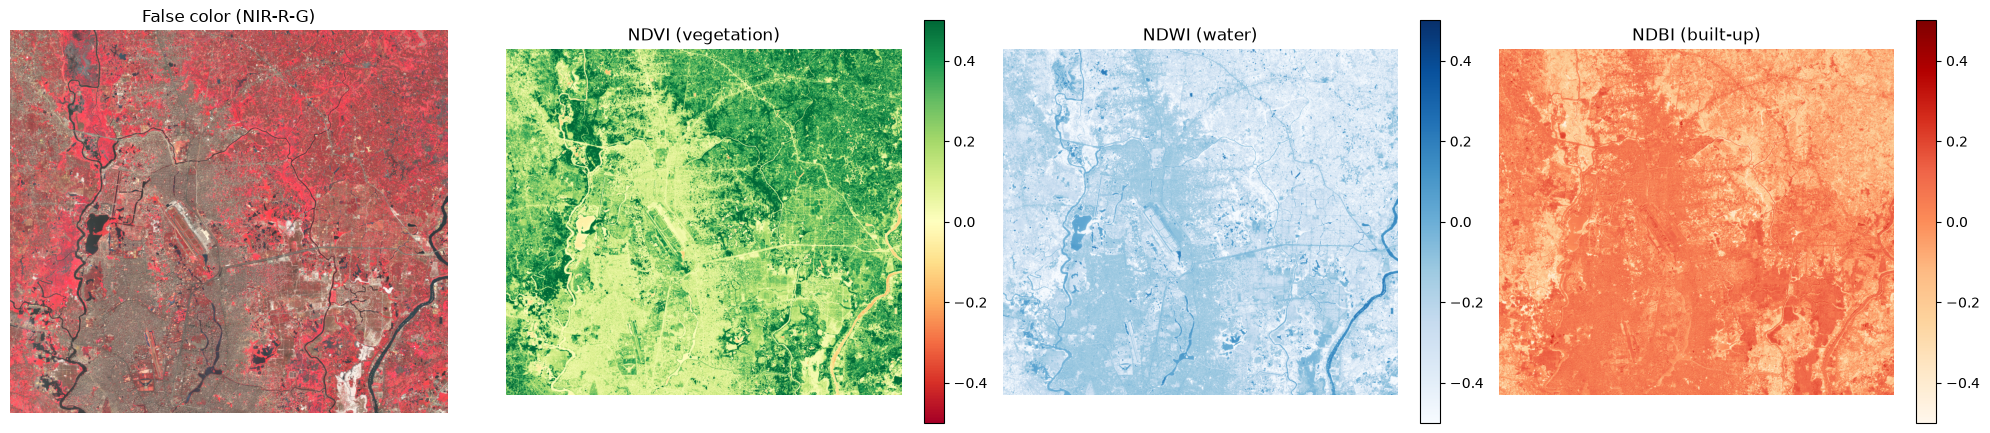

mean NDVI=0.244  NDWI=-0.256  NDBI=-0.022


In [4]:
ndvi_arr = ndvi(nir.values, red.values)
ndwi_arr = ndwi(green.values, nir.values)
ndbi_arr = ndbi(swir.values, nir.values)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
false_color = np.stack([nir.values, red.values, green.values], axis=-1)
# np.nanpercentile, not np.percentile: same real nodata-edge-pixel issue as
# the mean below -- np.percentile on an array containing any NaN returns NaN,
# which silently rendered this whole panel blank on the first run.
false_color = np.clip(false_color / np.nanpercentile(false_color, 98), 0, 1)
false_color = np.nan_to_num(false_color)
axes[0].imshow(false_color); axes[0].set_title('False color (NIR-R-G)')
for ax, data, title, cmap in zip(
    axes[1:], [ndvi_arr, ndwi_arr, ndbi_arr],
    ['NDVI (vegetation)', 'NDWI (water)', 'NDBI (built-up)'],
    ['RdYlGn', 'Blues', 'OrRd'],
):
    im = ax.imshow(data, cmap=cmap, vmin=-0.5, vmax=0.5)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

# np.nanmean, not .mean(): a real scene has a handful of nodata edge pixels
# (nan fraction ~5.6e-06 here) where the tile boundary doesn't align exactly
# with a source pixel -- a plain .mean() propagates those NaNs into the whole
# result. Caught by actually running this: the first version of this cell
# printed 'mean NDVI=nan' for a scene with 99.9994% real data.
print(f'mean NDVI={np.nanmean(ndvi_arr):.3f}  NDWI={np.nanmean(ndwi_arr):.3f}  NDBI={np.nanmean(ndbi_arr):.3f}')


## 4. Write a GeoTIFF (array -> georeferenced raster file)

The core raster-writing pattern every later phase reuses: an array plus its
affine transform and CRS is enough to write a file any GIS tool can open.

In [5]:
import os
os.makedirs('../data/processed', exist_ok=True)

indices_stack = np.stack([ndvi_arr, ndwi_arr, ndbi_arr]).astype('float32')
with rasterio.open(
    '../data/processed/dhaka_smoke_tile_indices.tif', 'w',
    driver='GTiff', height=indices_stack.shape[1], width=indices_stack.shape[2],
    count=3, dtype='float32', crs=stack.rio.crs, transform=transform,
) as dst:
    dst.write(indices_stack)
    dst.descriptions = ('NDVI', 'NDWI', 'NDBI')
print('wrote ../data/processed/dhaka_smoke_tile_indices.tif')


wrote ../data/processed/dhaka_smoke_tile_indices.tif


## 5. Vectorize: NDWI threshold -> real water polygons

`rasterio.features.shapes` turns a boolean raster mask into vector polygons in one
call -- the pixel-to-polygon direction of the raster/vector round trip.

In [6]:
water_mask = (ndwi_arr > 0.0).astype('uint8')
water_polygons = [
    shape(geom) for geom, value in shapes(water_mask, transform=transform)
    if value == 1
]
water_gdf = gpd.GeoDataFrame({'id': range(len(water_polygons))}, geometry=water_polygons, crs=stack.rio.crs)
water_gdf = water_gdf[water_gdf.geometry.area > 400]  # drop single/few-pixel slivers (<400 m^2)
water_gdf.to_file('../data/processed/dhaka_smoke_tile_water.shp')
print(f'{len(water_gdf)} water polygons after dropping slivers, '
      f'{water_gdf.geometry.area.sum() / 1e6:.2f} km^2 total')


1931 water polygons after dropping slivers, 15.12 km^2 total


## 6. Rasterize: district boundaries -> a zone-id raster

The other direction -- vector polygons burned into a raster -- using the real
Bangladesh district boundaries fetched by
[`scripts/fetch_boundaries.py`](../scripts/fetch_boundaries.py) (geoBoundaries,
CC BY 3.0 IGO).

districts in the smoke tile: ['Dhaka', 'Gazipur', 'Narayanganj']


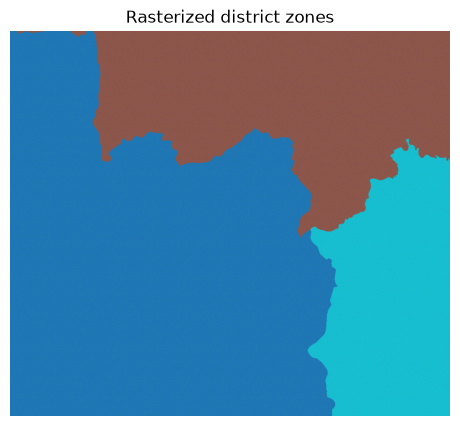

In [7]:
from rasterio.features import rasterize

districts = gpd.read_file('../data/raw/bgd_adm2.geojson').to_crs(stack.rio.crs)
smoke_box = box(*SMOKE_BBOX)
smoke_box_utm = gpd.GeoSeries([smoke_box], crs='EPSG:4326').to_crs(stack.rio.crs).iloc[0]
smoke_districts = districts[districts.intersects(smoke_box_utm)].reset_index(drop=True)
print('districts in the smoke tile:', smoke_districts['shapeName'].tolist())

zone_raster = rasterize(
    [(geom, i + 1) for i, geom in enumerate(smoke_districts.geometry)],
    out_shape=ndvi_arr.shape,
    transform=transform,
    fill=0,
    dtype='uint8',
)
plt.figure(figsize=(6, 5))
plt.imshow(zone_raster, cmap='tab10')
plt.title('Rasterized district zones')
plt.axis('off')
plt.show()


## 7. Zonal statistics -- the actual H0 deliverable

One table: real per-district mean NDVI/NDWI/NDBI, computed straight from the same
real Sentinel-2 scene -- this is the exact operation every later phase's
raster-to-health-data join depends on.

In [8]:
rows = []
for name, data in [('NDVI', ndvi_arr), ('NDWI', ndwi_arr), ('NDBI', ndbi_arr)]:
    stats = rasterstats.zonal_stats(
        smoke_districts, data, affine=transform, stats=['mean', 'std'], nodata=np.nan,
    )
    for district_name, stat in zip(smoke_districts['shapeName'], stats):
        rows.append({'district': district_name, 'index': name, 'mean': stat['mean'], 'std': stat['std']})

import pandas as pd
zonal_table = pd.DataFrame(rows).pivot(index='district', columns='index', values='mean')
zonal_table.to_csv('../data/processed/dhaka_smoke_tile_zonal_stats.csv')
zonal_table


index,NDBI,NDVI,NDWI
district,,,
Dhaka,-0.003295,0.205008,-0.224608
Gazipur,-0.067036,0.313820,-0.311734
Narayanganj,-0.009575,0.254014,-0.266378


## Notes / CRS pitfalls found while building this

- Sentinel-2 items on Planetary Computer don't always carry `proj:epsg` at the
  **item** level (it can live per-asset) -- `stackstac.stack(..., epsg=...)` failed
  with `Cannot pick a common CRS` until the UTM zone was supplied explicitly. The
  tile ID itself (`T46QBM` -> zone 46N -> EPSG:32646) is a fast, reliable way to
  get it for any Bangladesh scene without inspecting per-asset metadata.
- Loading directly in the scene's native UTM CRS instead of reprojecting to
  EPSG:4326 was ~7x faster for the same area in testing -- reprojecting every
  pixel of a multi-district bounding box to geographic coordinates is expensive;
  reprojecting the one small boundary polygon into the raster's CRS instead
  (`.to_crs(stack.rio.crs)`) is not.
- `rasterio.features.shapes` on a real NDWI threshold produces plenty of
  single-pixel-noise polygons (wet roofs, shadows) alongside real water bodies --
  filtering by a minimum area before writing the shapefile is not optional for
  real imagery, unlike the clean synthetic test cases in `tests/`.
- A real scene has a handful of nodata pixels where the requested bounding box
  doesn't land exactly on the source pixel grid (nan fraction ~5.6e-06 here --
  tiny, but nonzero). `array.mean()` and `np.percentile(...)` both propagate a
  single NaN to the whole result: the first run of this notebook printed
  `mean NDVI=nan` and rendered a completely blank false-color panel despite
  99.9994% real data. `np.nanmean` / `np.nanpercentile` fixed both -- worth
  remembering for every later phase, since any real AOI clip can produce this.

## Done when

- [x] One notebook goes from a raw Sentinel-2 scene + a real admin boundary file to
  a table of per-district mean NDVI/NDWI/NDBI.
- [x] Both raster<->vector directions demonstrated: NDWI threshold vectorized to
  water polygons; district boundaries rasterized to a zone raster.
- [x] A GeoTIFF and a shapefile written that QGIS (or any GIS tool) can open.
- [x] CRS pitfalls hit while building this written down above.